In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [26]:
df_roadacc = pd.read_csv('../data_processed/df_roadacc.csv')

In [27]:
median_density = df_roadacc['Road_accident_per_Kmq'].median()

df_roadacc['Density Group'] = np.where(
    df_roadacc['Road_accident_per_Kmq'] > median_density,
    'High Density',
    'Low Density'
)

df_roadacc['Density Group'].value_counts()

Density Group
Low Density     99751
High Density    91433
Name: count, dtype: int64

Hypothesis test

Do municipalities with high accident density have a different road accident rate per resident compared to municipalities with low accident density?

H0 : The average road accident rate per resident is the same in municipalities with high accident density and in municipalities with low accident density

H1 : The average road accident rate per resident is different between municipalities with high accident density and municipalities with low accident density.

Observed difference statistic: 0.002


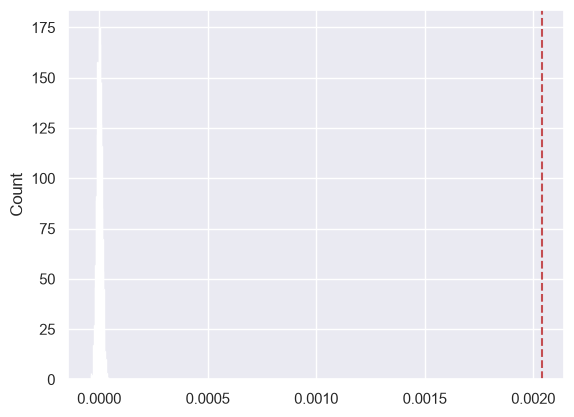

Values more extreme than observed: 0
p-value: 0.0
H0 rejected | the observed result is statistically significant | p-value <= alpha


In [ ]:
def abtest(df, exp_groups, exp_metric, n_rounds=2000, alpha=0.05): 

    a, b = df[exp_groups].unique()
    mu_a = np.mean(df[df[exp_groups]==a][exp_metric])
    mu_b = np.mean(df[df[exp_groups]==b][exp_metric])
    ab_mu_diff = mu_a - mu_b
    print('Observed difference statistic:', round(ab_mu_diff, 4))
    
    np.random.seed(1)
    mu_diff_samples = []
    for i in range(n_rounds): 
        # extract a subsample of 50% of data without replacement
        df_sample1 = df.sample(frac=0.5, replace=False)
        # use set() to get indexes of rows that were not extracted from df in previous step
        ix2 = set(df.index) - set(df_sample1.index)
        # create dataframe with other 50% of data
        df_sample2 = df.iloc[list(ix2)]
        # calculate difference in mean from each sample
        mu_diff_temp = np.mean(df_sample1[exp_metric]) - np.mean(df_sample2[exp_metric])
        # append sampled mean difference to mu_diff_samples list
        mu_diff_samples.append(mu_diff_temp)
    
    sns.histplot(mu_diff_samples)
    plt.axvline(ab_mu_diff, 0, 1, color='r', linestyle='--')
    plt.show()
    
    print('Values more extreme than observed:', sum([el >= ab_mu_diff for el in mu_diff_samples]))
    p_value = sum([el > ab_mu_diff for el in mu_diff_samples])/n_rounds
    print('p-value:', p_value)
    
    if p_value <= alpha: 
        print('H0 rejected | the observed result is statistically significant | p-value <= alpha')
    else: 
        print('H0 accepted | the observed result is not statistically significant | p-value > alpha')
        
    #return {'samples': mu_diff_samples, 'pvalue': p_value}

abtest(
    df_roadacc,
    'Density Group',
    'Road_accidentS_per_resident',
    n_rounds=2000,
    alpha=0.05
)